In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
import matplotlib.lines as mlines

In [2]:
# Note:
# all standard constants and units are from the IAU definitions listed in Mamajek et al. (2015)
Rsun_meter = 6.957e8 
Rearth_meter = 6.3781e6 # note this is the "zero tide" equatorial radius of Earth

def calc_dx_elongation(Rstar, phi, theta=0):
    ## Calculates difference in sky plane-projected x position
    ##    of point on stellar surface before (at phase theta)
    ##    versus after rotation (at phase theta+phi)
    ## inputs:
    ##    Rstar = stellar radius, in [Rsun]
    ##    theta = initial position angle in [deg]
    ##    phi = additional rotation in [deg]
    ## outputs:
    ##   dx in units [m]

    # -- convert Rstar to [m]
    Rstar_meter = Rstar * Rsun_meter
    # -- convert angles to [radians]
    theta_radians = np.deg2rad(theta)
    phi_radians = np.deg2rad(phi)

    thetanew_radians = theta_radians + phi_radians
    # -- calculate dx in [m]
    dx = Rstar_meter*(np.sin(thetanew_radians) - np.sin(theta_radians))
    
    return dx

def calc_phi(Prot, Tcross):
    ## Calculates the angle by which the star rotates during
    ##    the crossing of a spot (assumed to be a single point on the surface)
    ## inputs:
    ##    Prot = rotation period of the star, in [day]
    ##    Tcross = spot crossing time, in [min]
    ## outputs:
    ##    phi in [deg]

    # -- convert Tcross to day
    Tcross_day = Tcross / 60. / 24.
    # -- calculate phi in [deg]
    phi = 360.*(Tcross_day/Prot)
    return phi

def calc_Tcross():
    ## to be filled in
    ## should be able to calculate crossing time given Vorb and some measure of the true spot "size"
    ## return crossing time in [min]
    return 20.

def get_elongations(Rstar, Prot, Tcross, theta=0):
    ## Vorb and spotsize dependencies to be filled in and replace Tcross input
    ## wrapper around above functions to get end-to-end to elongation

    #Tcross = calc_Tcross(Vrot, spotsize)
    phi = calc_phi(Prot, Tcross)
    dx_meter = calc_dx_elongation(Rstar, phi, theta)
    dx_Rearth = dx_meter / Rearth_meter
    return dx_Rearth

In [3]:
Rstar = 1.0 # solar radius star
Prot_vals = np.array([1.0, 3.0, 5.0, 10.0, 20.0])
Tcross_vals = np.linspace(5., 30., 20)

elong_curves = np.zeros((len(Prot_vals), len(Tcross_vals)))
elong_curves2 = np.zeros((len(Prot_vals), len(Tcross_vals)))
for i, Prot in enumerate(Prot_vals):
    for j, Tcross in enumerate(Tcross_vals):
        elong_curves[i,j] = get_elongations(Rstar, Prot, Tcross, theta=0)
        elong_curves2[i,j] = get_elongations(Rstar, Prot, Tcross, theta=45.0)


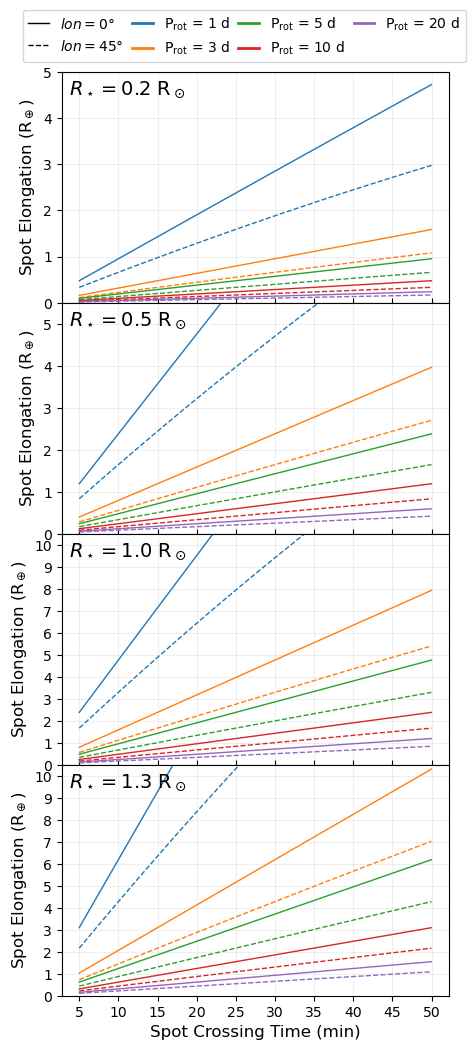

In [4]:
colors = np.array(['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown'])
Rstar_vals = np.array([0.2, 0.5, 1.0, 1.3])
Prot_vals = np.array([1.0, 3.0, 5.0, 10.0, 20.0])
Tcross_vals = np.linspace(5., 50., 20)

fig, ax = plt.subplots(figsize=(5,12), nrows=4, sharex=True)
plt.subplots_adjust(hspace=0.)
for r, Rstar in enumerate(Rstar_vals):
    ax[r].text(0.02, 0.9, r'$R_\star = %.1f$ R$_\odot$'%(Rstar), fontsize=14, c='black', transform=ax[r].transAxes)
    ax[r].grid(visible=True, alpha=0.2)
    elong_curves = np.zeros((len(Prot_vals), len(Tcross_vals)))
    elong_curves2 = np.zeros((len(Prot_vals), len(Tcross_vals)))
    for i, Prot in enumerate(Prot_vals):
        for j, Tcross in enumerate(Tcross_vals):
            elong_curves[i,j] = get_elongations(Rstar, Prot, Tcross, theta=0)
            elong_curves2[i,j] = get_elongations(Rstar, Prot, Tcross, theta=45.0)
            
        ax[r].plot(Tcross_vals, elong_curves[i], lw=1, ls='solid', c=colors[i])
        ax[r].plot(Tcross_vals, elong_curves2[i], lw=1, ls='--', c=colors[i])
    if r != 3:
        ax[r].xaxis.set_tick_params(labelbottom=False, direction='in')
    ax[r].set_ylabel(r'Spot Elongation (R$_\oplus$)', fontsize=12)
    ax[r].xaxis.set_major_locator(MultipleLocator(5))
    ax[r].yaxis.set_major_locator(MultipleLocator(1))
ax[0].set_ylim(0,5)
ax[1].set_ylim(0,5.5)
ax[2].set_ylim(0,10.5)
ax[3].set_ylim(0,10.5)
ax[3].set_xlabel('Spot Crossing Time (min)', fontsize=12)

handle_theta0  = mlines.Line2D([], [], color='black', lw=1, ls='solid', label=r'$lon = 0°$')
handle_theta45 = mlines.Line2D([], [], color='black', lw=1, ls='--',   label=r'$lon = 45°$')
prot_handles = [
    mlines.Line2D([], [], color=colors[i], lw=2, ls='solid',
                  label=r'P$_{\rm rot}$ = %.0f d' % Prot_vals[i])
    for i in range(len(Prot_vals))
]
all_handles = [handle_theta0, handle_theta45] + prot_handles
ax[0].legend(handles=all_handles, fontsize=10, ncol=4, columnspacing=0.6, handlelength=1.5, loc=(-.1,1.04))

plt.savefig('./figures/Figure12_elongationmodels.pdf', dpi=600, bbox_inches='tight')
plt.show()